In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = np.load('/home/kulraj/nepali_ocr/data/dataset.npz')

# See what's inside
print("Keys inside dataset.npz:", data.files)

Keys inside dataset.npz: ['arr_1', 'arr_0', 'arr_3', 'arr_2']


In [3]:
for key in data.files:
    arr = data[key]
    print(f"{key} → shape: {arr.shape}, dtype: {arr.dtype}, min: {arr.min()}, max: {arr.max()}")

arr_1 → shape: (78200,), dtype: int64, min: 1, max: 46
arr_0 → shape: (78200, 32, 32), dtype: uint8, min: 0, max: 255
arr_3 → shape: (13800,), dtype: int64, min: 1, max: 46
arr_2 → shape: (13800, 32, 32), dtype: uint8, min: 0, max: 255


Train: (78200, 32, 32), Test: (13800, 32, 32)
Classes: 46


/tmp/ipykernel_13806/348853543.py:23: UserWarning: Glyph 2408 (\N{DEVANAGARI DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13806/348853543.py:23: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_13806/348853543.py:23: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13806/348853543.py:23: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13806/348853543.py:23: UserWarning: Glyph 2359 (\N{DEVANAGARI LETTER SSA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13806/348853543.py:23: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13806/348853543.py:23: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

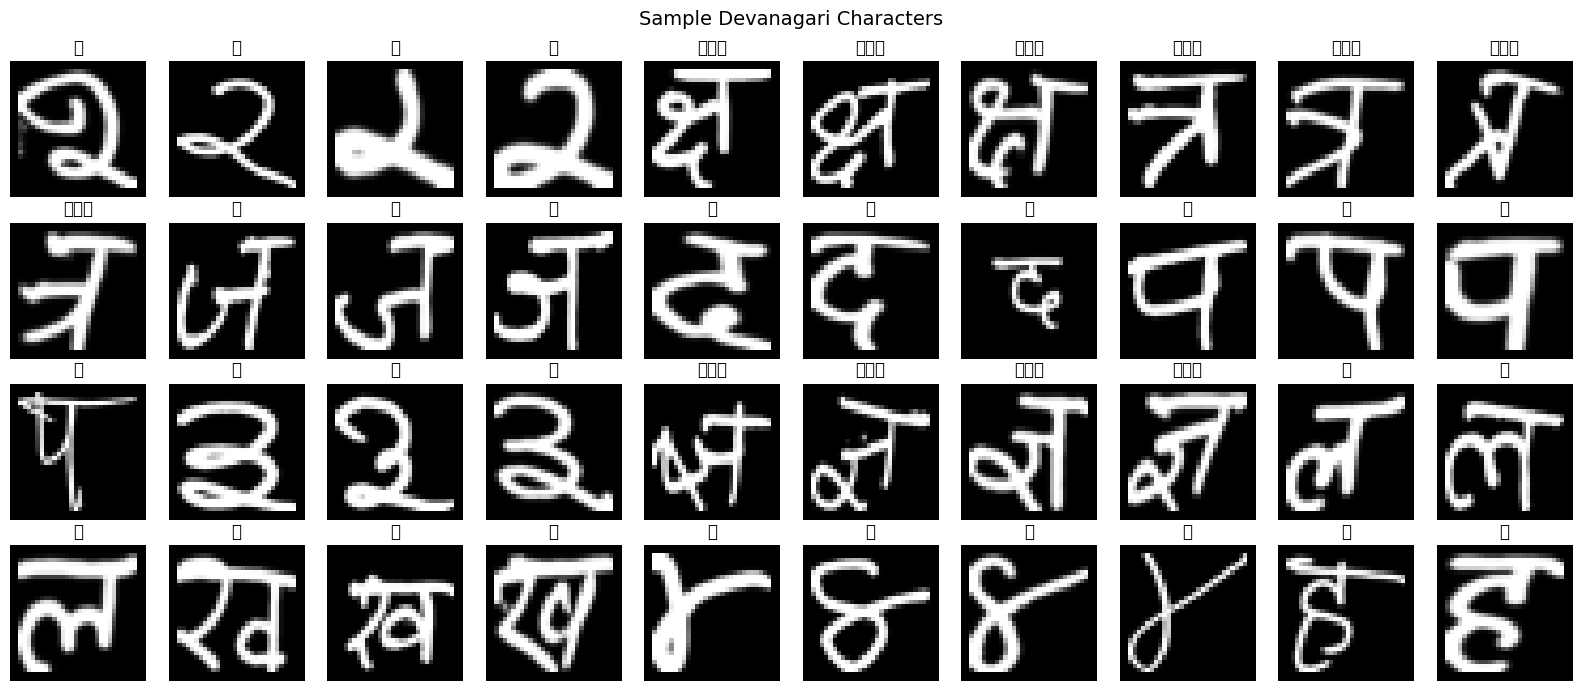

In [4]:
X_train = data['arr_0']
y_train = data['arr_1']
X_test  = data['arr_2']
y_test  = data['arr_3']

# 46 Devanagari character class names
CLASS_NAMES = ['क','ख','ग','घ','ङ','च','छ','ज','झ','ञ',
               'ट','ठ','ड','ढ','ण','त','थ','द','ध','न',
               'प','फ','ब','भ','म','य','र','ल','व','श',
               'ष','स','ह','क्ष','त्र','ज्ञ',
               '०','१','२','३','४','५','६','७','८','९']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {len(CLASS_NAMES)}")

# Show sample images
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i * 500], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i * 500] - 1], fontsize=12)
    ax.axis('off')
plt.suptitle('Sample Devanagari Characters', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Install Noto font for Devanagari
import subprocess
subprocess.run(['sudo', 'apt', 'install', '-y', 'fonts-noto'], capture_output=True)

# Find and register it
fm.fontManager.__init__()
noto_fonts = [f for f in fm.findSystemFonts() if 'Noto' in f and 'Devanagari' in f]
print("Found fonts:", noto_fonts)

Found fonts: ['/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf', '/usr/share/fonts/truetype/noto/NotoSansDevanagari-Bold.ttf', '/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf', '/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Regular.ttf']


Using font: /usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf


/tmp/ipykernel_13806/25369940.py:18: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_13806/25369940.py:18: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/home/kulraj/nepali_ocr/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


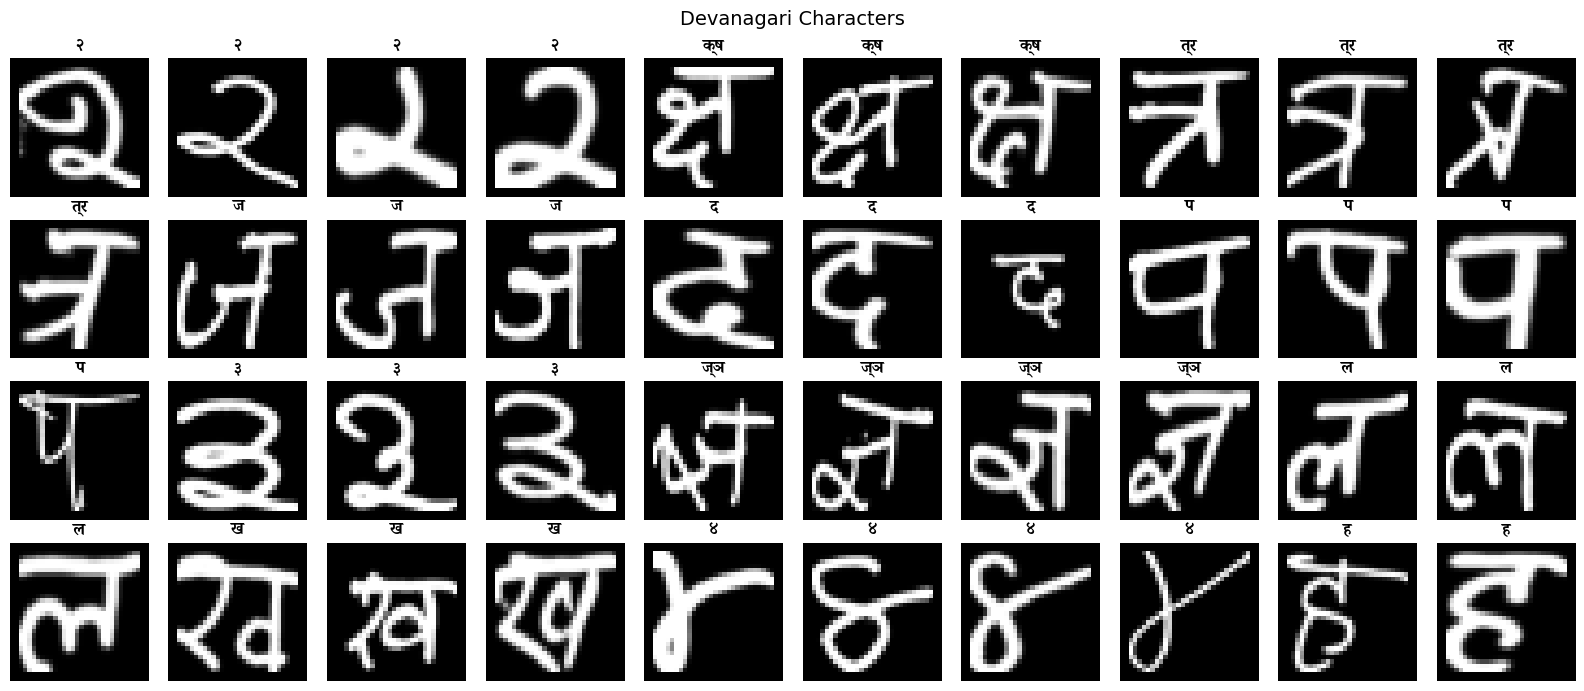

In [6]:
# Set Noto Devanagari as the font
from matplotlib import rcParams

if noto_fonts:
    prop = fm.FontProperties(fname=noto_fonts[0])
    print("Using font:", noto_fonts[0])
else:
    print("Font not found, trying manual path")
    prop = fm.FontProperties(fname='/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf')

# Redraw with correct font
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i * 500], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i * 500] - 1], fontproperties=prop, fontsize=12)
    ax.axis('off')
plt.suptitle('Devanagari Characters', fontsize=14)
plt.tight_layout()
plt.show()